# Statistical Analysis of the Global Multi-Hazard Framework

This notebook applies the statistical component of the multi-hazard coastal screening framework to the processed global coastal-transect dataset. The analysis converts the three hazard variables—coastal flooding, shoreline erosion, and land subsidence—into spatial indicators that describe **hazard concentration**, **compound flood amplification**, and **hotspot priority**.

The workflow is organized into four main stages:

1. **Set up the analysis environment and read the processed transect dataset.**
2. **Characterize multi-hazard burden** by scoring the individual hazards, assigning transects to a common spatial aggregation unit, identifying locally extreme conditions, and aggregating the resulting hazard concentration.
3. **Quantify compound flood amplification** using the ratio between conditional and background flood probabilities.
4. **Combine burden and amplification into the Hotspot Priority Index (HPI)** and evaluate how regional amplification differs from the global reference condition.

The notebook is intended for screening rather than site-scale hazard prediction. The resulting indicators therefore identify locations where multiple hazards are concentrated and/or where erosion and subsidence are associated with an elevated probability of extreme flooding. These locations can subsequently be prioritized for more detailed physical assessment.


In [47]:
# Expected: imports complete without errors and project-specific hazard/plotting functions become available.
# ============================================================
# Development settings
# ============================================================
%load_ext autoreload
%autoreload 2

# ============================================================
# Standard library
# ============================================================
import sys
from pathlib import Path
import matplotlib.colors as mcolors
import colorcet as cc
# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# ============================================================
# Scientific / geospatial libraries
# ============================================================
import numpy as np
import pandas as pd
import geopandas as gpd
import h3

# ============================================================
# Project modules
# ============================================================
# from src.hazard_framework import (
#     hazard_scoring,
#     assign_aggregation_framework,
#     calculate_burden,
# )

from src.hazard_framework import *
from src.plotting_function import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"

print("Project root:", PROJECT_ROOT)
print("Data:", DATA_DIR)
print("Figures:", FIGURE_DIR)

Project root: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification
Data: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data
Figures: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\figures


## 1. Read the processed global coastal-hazard dataset

The statistical analysis starts from `3hazard_final_update.parquet`, a processed geospatial dataset containing the coastal transects and the hazard variables required by the framework. At this stage the upstream data preparation has already harmonized the global hazard datasets so that flooding, shoreline change, and land subsidence can be evaluated at a common transect representation.


In [ ]:
gdf = gpd.read_parquet(DATA_DIR / 'mapped_hazard.parquet')

## 2. Multi-Hazard Burden ($MH_B$)

The Multi-Hazard Burden represents the **local concentration of severe coastal-hazard conditions**. Its calculation is deliberately separated into scoring, spatial aggregation, extreme classification, and burden calculation so that the physical hazard information and the spatial screening framework remain transparent.

### 2.1 Score the individual hazards

Each transect is first converted from raw hazard magnitudes into the hazard-scoring representation used by the framework. Flooding, erosion, and subsidence have different units and physical ranges, so they cannot be combined directly. `hazard_scoring()` standardizes their contribution according to the hazard classes defined in the methodology. Shoreline change is represented in terms of erosion for the multi-hazard analysis, such that retreat contributes to the erosion hazard component.

In [ ]:
gdf = hazard_scoring(gdf)

### 2.2 Assign a common spatial aggregation framework

Individual transects are too fine-grained for robust global comparison, particularly because data availability and the number of valid transects vary geographically. The transects are therefore assigned to a common **H3 spatial grid**. Here, H3 resolution 2 is used as the regional aggregation unit for the global screening analysis.

The aggregation unit provides the spatial support over which local extremes, burden, and amplification are evaluated. Using the same unit throughout the workflow ensures that the burden and amplification indicators can later be joined consistently when calculating HPI.

The aggregation framework is not restricted to the H3 grid. Alternative spatial units can be specified by setting `framework='polygon'` and providing a polygon dataset with the corresponding regional identifier. In this case, each transect is assigned to the polygon in which it is located, and the subsequent extreme classification, burden, and amplification calculations are performed using these polygon units instead of H3 cells. This allows the same workflow to be applied at other spatial scales or to predefined geographic regions, such as coastal regions or administrative units. The H3 framework is used in the present global analysis because it provides a spatially consistent aggregation unit independent of administrative or regional boundaries.


In [ ]:
gdf = assign_aggregation_framework(gdf,framework='h3',resolution=2)

### 2.3 Identify locally extreme hazard conditions

The framework next distinguishes the upper tail of each hazard distribution from the background conditions. `classify_extreme()` applies the extreme-hazard definition used in the methodology within the assigned aggregation framework, allowing the screening to focus on unusually severe flood, erosion, and subsidence conditions rather than simply comparing raw magnitudes.


In [ ]:
gdf = classify_extreme(gdf)

Flood threshold: 2.6505063422520956 Erosion threshold: 1.0133076 Subsidence threshold: 1.0


### 2.4 Calculate Multi-Hazard Burden

`calculate_burden()` aggregates the transect-level hazard classifications to the H3 cells. The resulting Multi-Hazard Burden ($MH_B$) summarizes how strongly multiple severe hazards are concentrated within each spatial unit while accounting for the amount of transect information represented by that cell.

In the implemented formulation, the mapped burden combines the **local hazard concentration (LHC)** with a logarithmic representation of the number of transects in the cell. This prevents a cell containing only a very small number of observations from being interpreted in the same way as a cell where the multi-hazard signal is supported by many coastal transects.

A high $MH_B$ therefore indicates a regional cell where severe hazard conditions are comparatively concentrated and supported by a substantial coastal sample. It does **not** by itself indicate that flooding is statistically amplified by erosion or subsidence; that interaction is evaluated separately in the next section.


In [ ]:
burden = calculate_burden(gdf)

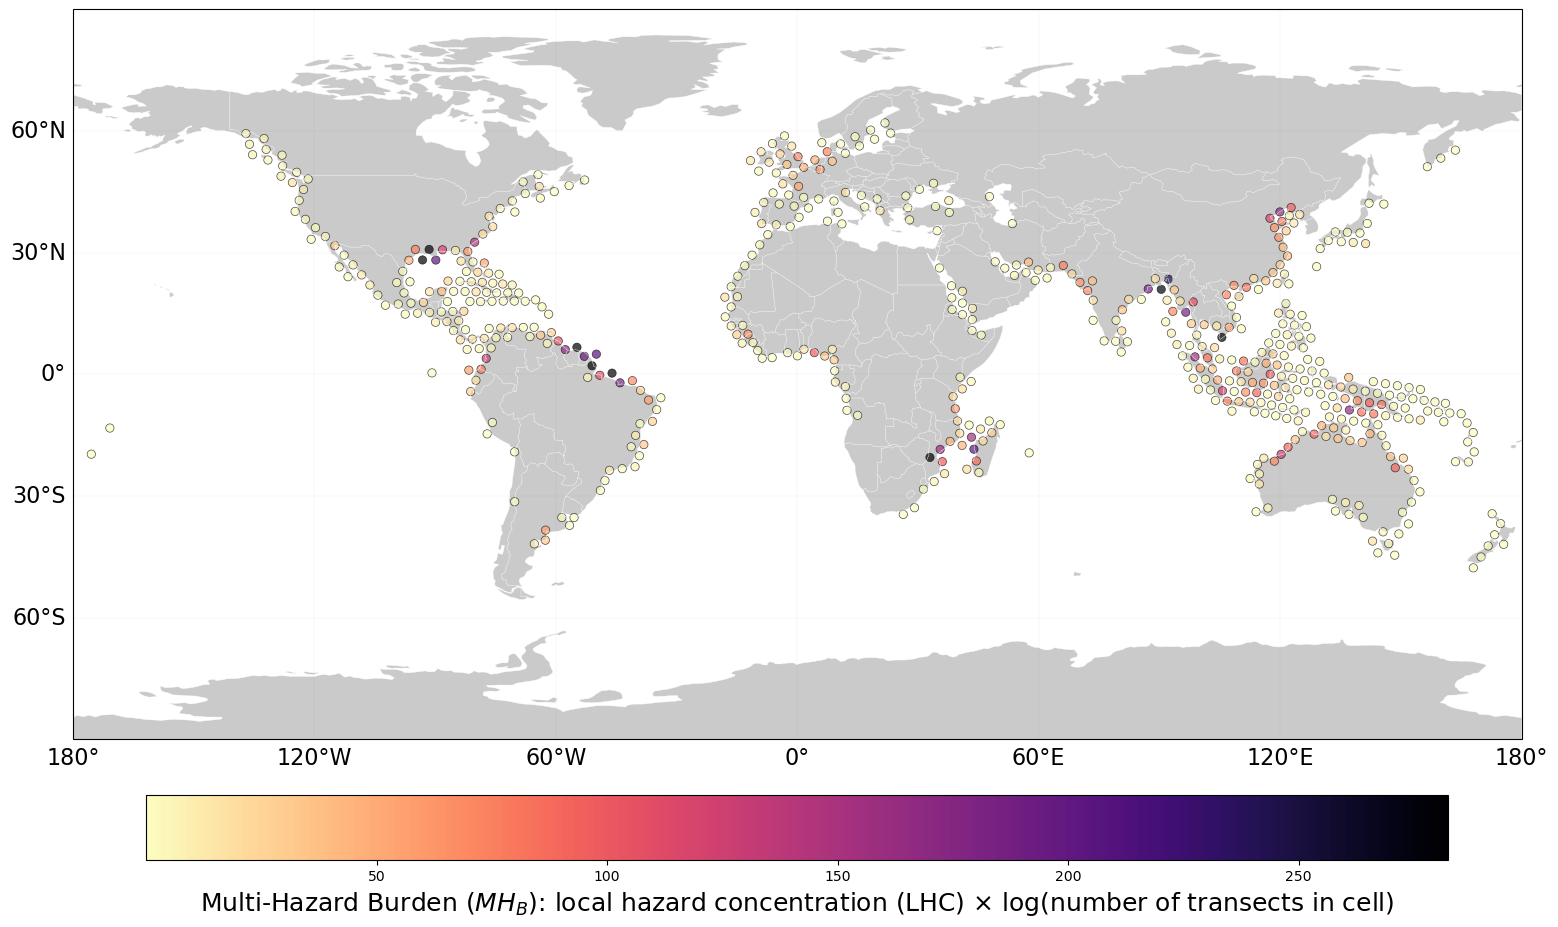

In [ ]:

fig, ax = initialize_map(figsize=(24,12))

key = 'MHB'

vmin = burden[key].quantile(0.01)
vmax = burden[key].quantile(0.99)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

burden.plot(
    column=key,
    cmap=plt.cm.magma_r,
    ax=ax,
    norm=norm,
    legend=True,
    edgecolor="black",
    alpha=0.7,
    linewidth=0.5,
        legend_kwds={
        # "label": "Conditional flood amplification ratio",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

cbar_ax = fig.axes[-1]
cbar_ax.set_xlabel(
    r"Multi-Hazard Burden ($MH_B$): local hazard concentration (LHC) × log(number of transects in cell)",
    fontsize=18
)

plt.savefig(FIGURE_DIR / 'ch5_mhb.png')

## 3. Compound flood amplification

Multi-Hazard Burden identifies where severe hazards are concentrated, but it does not describe whether the presence of erosion and subsidence changes the likelihood of extreme flooding. The amplification analysis addresses this second component of the framework.

For each spatial aggregation unit, the compound amplification factor compares the conditional probability of extreme flooding when erosion and subsidence are also extreme with the background probability of extreme flooding:

$$
A_{F|ES}=\frac{P(F\mid E\cap S)}{P(F)}.
$$

Here, $F$, $E$, and $S$ denote the extreme flood, erosion, and subsidence states defined in the preceding classification step. The ratio is interpreted relative to unity:

- $A_{F|ES} > 1$: extreme flooding is proportionally more frequent under the joint extreme erosion–subsidence condition than in the background sample.
- $A_{F|ES} = 1$: the conditional and background flood probabilities are equivalent.
- $A_{F|ES} < 1$: extreme flooding is proportionally less frequent under the joint condition.

The metric is a statistical screening indicator. It identifies spatial association in the hazard structure and should not, on its own, be interpreted as proof of a causal physical interaction.


In [ ]:
amplification = calculate_amplification(gdf)
amplification.head()

,h3,n_total,n_F,n_E,n_S,n_FE,n_FS,n_ES,n_FES,pF,pF_E,pF_S,pF_ES,amp_FE,amp_FS,amp_FES,lat,lon,geometry
0,820887fffffffff,1928.0,73.0,43.0,1928.0,3.0,73.0,43.0,3.0,0.037863,0.069767,0.037863,0.069767,1.842625,1.0,1.842625,60.191218,18.258530,POINT (18.25853 60.19122)
1,820897fffffffff,2914.0,10.0,48.0,2914.0,0.0,10.0,48.0,0.0,0.003432,0.000000,0.003432,0.000000,0.000000,1.0,0.000000,57.949132,19.232213,POINT (19.23221 57.94913)
2,82089ffffffffff,3612.0,0.0,113.0,3612.0,0.0,0.0,113.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,59.456967,23.223130,POINT (23.22313 59.45697)
3,8208b7fffffffff,2275.0,41.0,45.0,2275.0,2.0,41.0,45.0,2.0,0.018022,0.044444,0.018022,0.044444,2.466125,1.0,2.466125,58.560335,14.388555,POINT (14.38856 58.56034)
4,820997fffffffff,756.0,216.0,49.0,756.0,28.0,216.0,49.0,28.0,0.285714,0.571429,0.285714,0.571429,2.000000,1.0,2.000000,57.093359,6.128675,POINT (6.12868 57.09336)


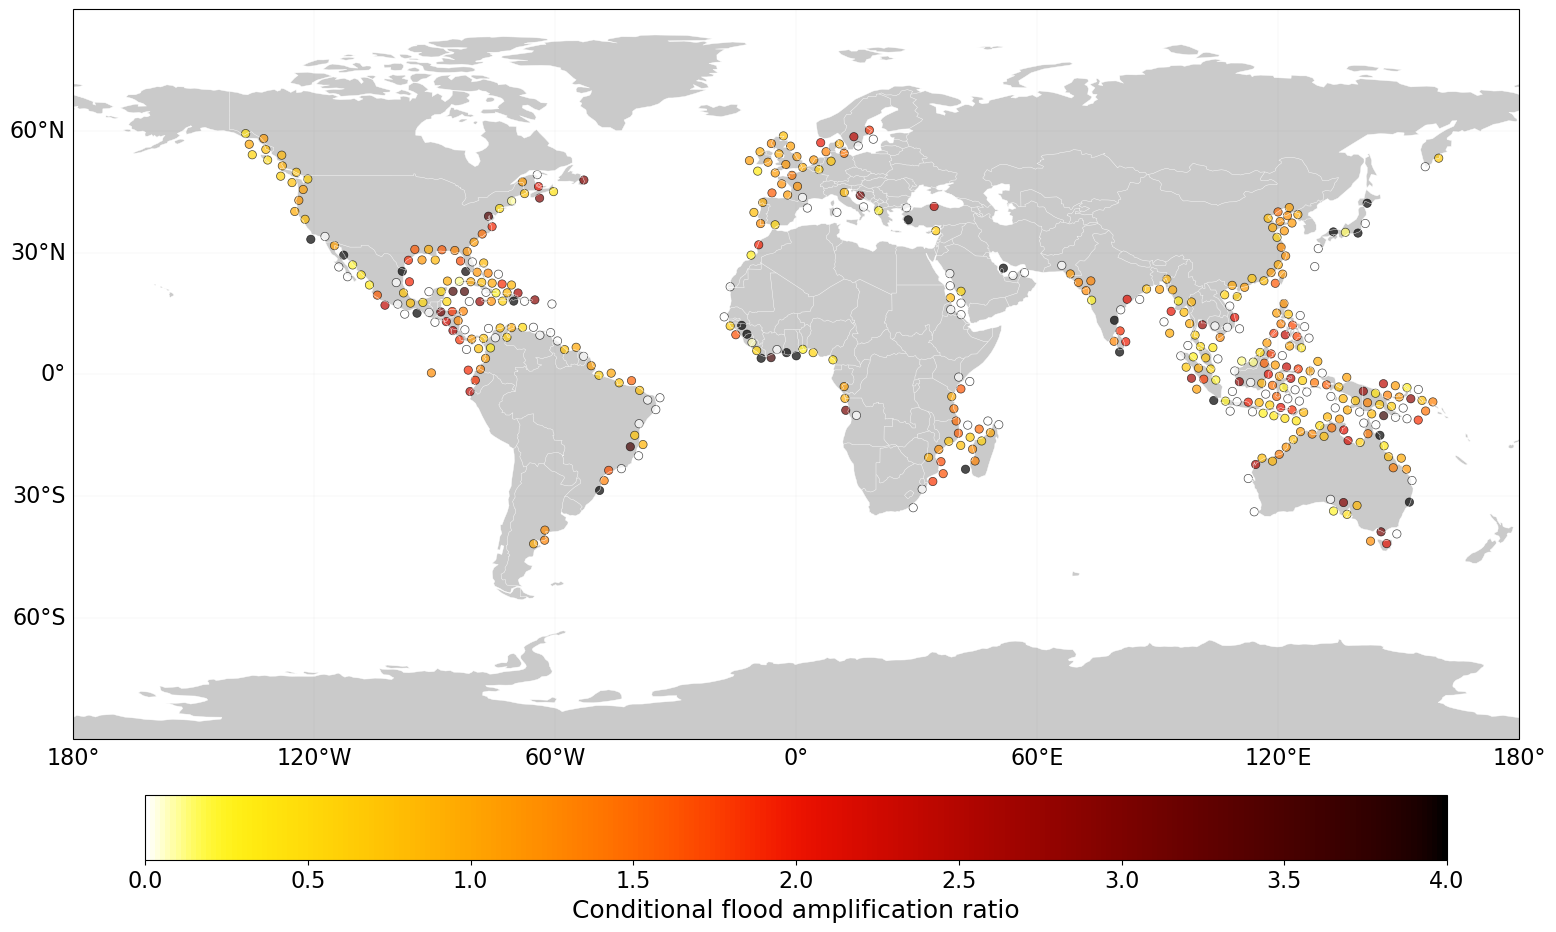

In [ ]:

fig, ax = initialize_map(figsize=(24,12))

key = 'amp_FES'

# vmin = amplification[key].quantile(0.01)
# vmax = amplification[key].quantile(0.99)

norm = mcolors.Normalize(
    vmin=0,
    vmax=4
)

# norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

amplification.plot(
    column=key,
    cmap=cc.m_fire_r,
    norm=norm,
    ax=ax,
    legend=True,
    edgecolor="black",
    alpha=0.7,
    linewidth=0.5,
        legend_kwds={
        # "label": "Conditional flood amplification ratio",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

# get colorbar axis
cbar_ax = fig.axes[-1]

# change colorbar label fontsize
cbar_ax.set_xlabel(
    "Conditional flood amplification ratio",
    fontsize=18
)

# change colorbar tick fontsize
cbar_ax.tick_params(labelsize=16)


plt.savefig(FIGURE_DIR / 'ch5_amp.png')

## 4. Hotspot Priority Index (HPI)

The final screening indicator combines the two complementary dimensions developed above: **multi-hazard burden** describes where severe hazards are concentrated, whereas **amplification** describes where the joint erosion–subsidence condition is associated with a different probability of extreme flooding.

`calculate_HPI()` joins the burden and amplification results using the common H3 framework and calculates the Hotspot Priority Index using `amp_FES` as the amplification component. The purpose is to prioritize cells that are important in both dimensions rather than selecting locations from hazard magnitude or statistical amplification alone.

Consequently, a high HPI should be interpreted as a **screening priority** for follow-up investigation. It identifies locations where the multi-hazard signal is both substantial and relevant to compound flood amplification, but it is not a direct estimate of expected damage, exposure, or risk.


In [ ]:
hpi = calculate_HPI(
    burden=burden,
    amplification=amplification,
    amp_column="amp_FES",
    framework="h3",
)

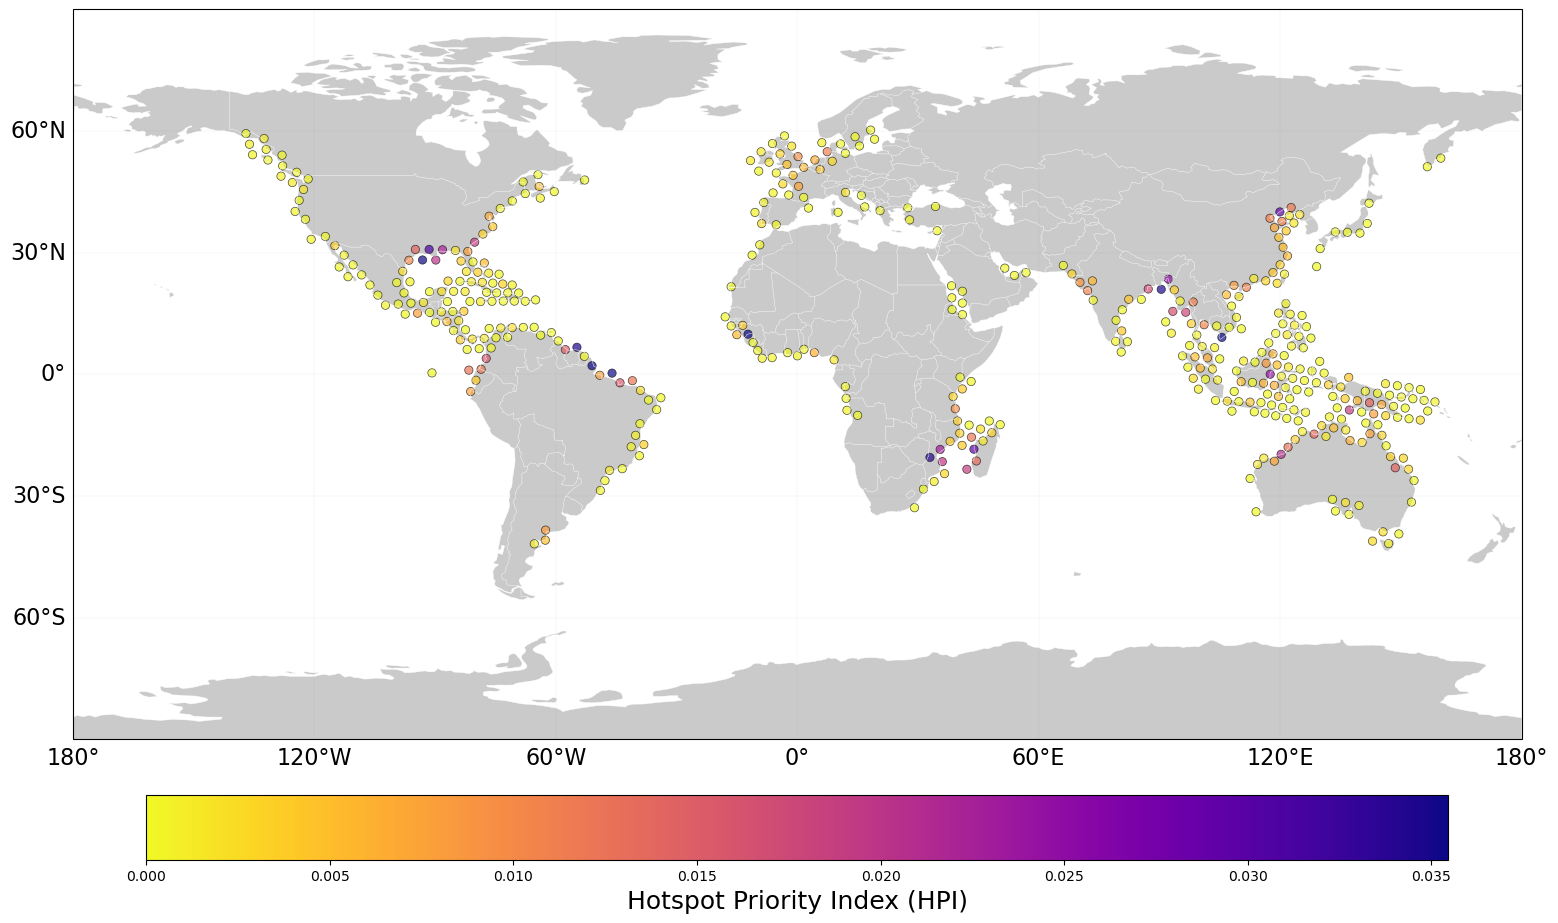

In [ ]:
fig, ax = initialize_map(figsize=(24,12))

key = 'HPI'

vmin = hpi[key].quantile(0.01)
vmax = hpi[key].quantile(0.99)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

hpi.plot(
    column=key,
    cmap=plt.cm.plasma_r,
    ax=ax,
    norm=norm,
    legend=True,
    edgecolor="black",
    alpha=0.7,
    linewidth=0.5,
        legend_kwds={
        # "label": "Conditional flood amplification ratio",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

cbar_ax = fig.axes[-1]
cbar_ax.set_xlabel(
    r"Hotspot Priority Index (HPI)",
    fontsize=18
)


plt.savefig(FIGURE_DIR / 'ch5_hpi.png')

### 5. Examine the HPI component space and data distribution

The distribution of the two normalized components used to construct the Hotspot Priority Index is examined. The HPI combines the normalized Multi-Hazard Burden (`N_mhb`) and compound flood amplification (`N_amp`), so similar HPI values can arise from different combinations of these two components. This also highlight unequal contribution of its constituents.

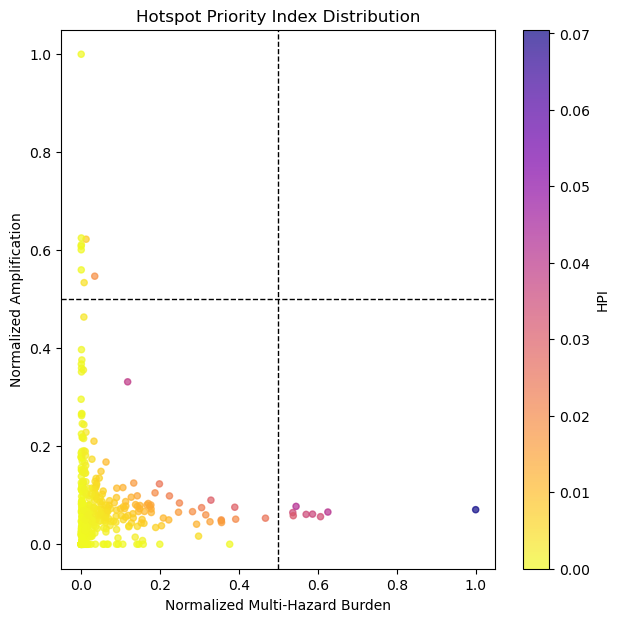

In [19]:
plt.figure(figsize=(7,7))

plt.scatter(
    hpi['N_mhb'],
    hpi['N_amp'],
    c=hpi['HPI'],
    cmap='plasma_r',
    s=20,
    alpha=0.7
)

plt.axvline(0.5,color='k',ls='--',lw=1)
plt.axhline(0.5,color='k',ls='--',lw=1)

plt.xlabel("Normalized Multi-Hazard Burden")
plt.ylabel("Normalized Amplification")
plt.title("Hotspot Priority Index Distribution")

plt.colorbar(label='HPI')

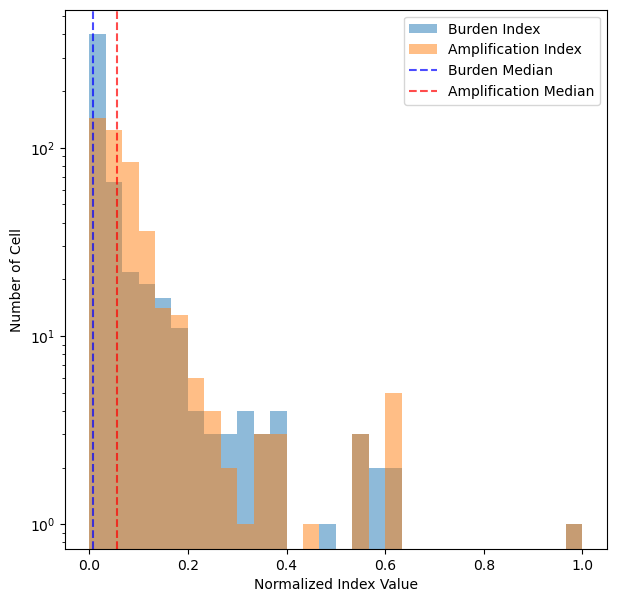

In [20]:
plt.figure(figsize=(7,7))
plt.hist(hpi['N_mhb'], bins=30, alpha=0.5, label='Burden Index')
plt.hist(hpi['N_amp'], bins=30, alpha=0.5, label='Amplification Index')
plt.axvline(hpi['N_mhb'].median(),
            color='blue', ls='--', alpha=0.7,label='Burden Median')

plt.axvline(hpi['N_amp'].median(),
            color='red', ls='--', alpha=0.7,label='Amplification Median')
plt.yscale('log')
plt.xlabel('Normalized Index Value')
plt.ylabel('Number of Cell')
plt.legend()

In [21]:
# find top location for each hazard regime
top_hotspots = hpi.sort_values("HPI", ascending=False).head(10)
low_hotspots = hpi.sort_values("HPI", ascending=True).head(10)
top_burden = hpi.sort_values("MHB", ascending=False).head(10)
top_amp = hpi.sort_values("amp", ascending=False).head(10)
hi_hi = (hpi[
    (hpi['MHB'] > hpi['MHB'].median()) &
    (hpi['amp'] > hpi['amp'].median())
]
.sort_values('HPI', ascending=False)
.head(10)
)

loc_index = [top_hotspots.index,hi_hi.index,top_burden.index,top_amp.index,low_hotspots.index]
h3_loc = []
for idx_list in loc_index:
    h3_loc.append(hpi['h3'].loc[idx_list].tolist())

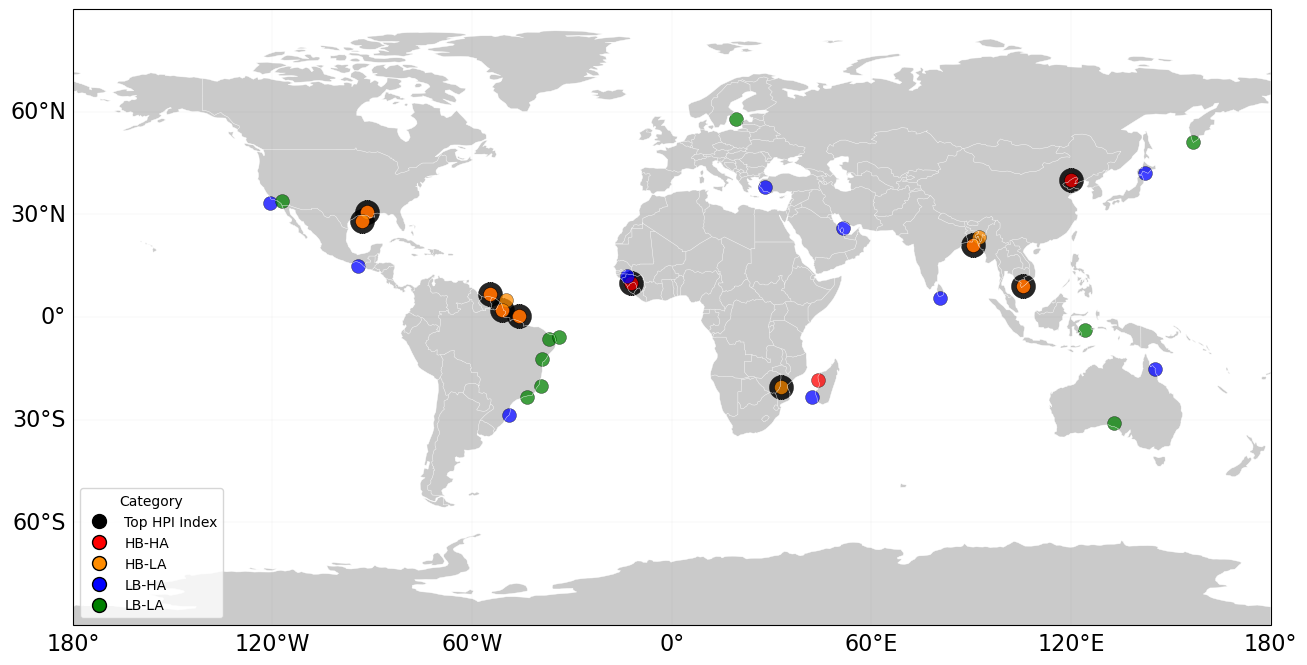

In [22]:
# color = ['red','darkorange','blue','green']
color = ['black','red','darkorange','blue','green']

fig,ax = initialize_map()

top_hotspots.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    markersize=300,
    # marker='p',
    color='black',
    alpha=0.85,
    edgecolor="black",
    linewidth=0.3,
    )

for col, idx in zip(color, h3_loc):
    df_filtered = hpi[hpi['h3'].isin(idx)]

    df_filtered.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        markersize=100,
        color=col,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3,
    )



from matplotlib.lines import Line2D

# labels = [
#     'Top HPI Index',
#     'High Burden - High Amplification',
#     'High Burden - Low Amplification',
#     'Low Burden - High Amplification',
#     'Low Burden - Low Amplification',
# ]

labels = [
    'Top HPI Index',
    'HB-HA',
    'HB-LA',
    'LB-HA',
    'LB-LA',
]

handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=c,
        markeredgecolor='black',
        markersize=10,
        label=l,
        alpha = 1
    )
    for c, l in zip(color, labels)
]

ax.legend(
    handles=handles,
    title='Category',
    loc='lower left'
)

### 6. Examine the Hazard Structure of Representative Locations

Representative spatial units are selected from the contrasting burden–amplification regimes identified above to examine the transect-level hazard structure underlying the aggregated indicators. The purpose of this analysis is to interpret the aggregated burden and amplification indicators in terms of the original hazard observations from which they were derived.


In [ ]:
# parameter of the selected location
selected = {
    'hi_hi' : [96],
    'hi_lo': [453],
    'lo_hi': [62],
    'lo_lo': [116]
}

loc_label = ['Bohai Sea', 
             'Mozambique', 'Southern California', 'Morocco']

selected_location = [x[0] for x in selected.values()]
hpi[["concentration", 'n_total_x', 'MHB',"amp_FES", "HPI", "HPI_rank"]].loc[selected_location].round(9)


,concentration,n_total_x,MHB,amp_FES,HPI,HPI_rank
96,24.073722,5263,172.011467,1.464491,0.029598,10
453,53.125000,736,317.223285,0.915383,0.034119,8
62,0.068666,4369,0.095191,16.277778,0.000170,291
116,0.054975,3638,0.060396,0.303896,0.000002,347


In [ ]:
# -----------------------------------
# build plotting dataframe
# -----------------------------------
rows = []

for group, idx_list in selected.items():

    for idx in np.atleast_1d(idx_list):

        h3_id = hpi['h3'].loc[idx]

        df_group = gdf[gdf['h3'].isin([h3_id])].copy()
        df_group['group'] = f'{group}_{idx}'

        rows.append(df_group)

hazard_structure = pd.concat(rows, ignore_index=True)

hazard_structure = hazard_structure.copy()

hazard_structure["geometry"] = hazard_structure.to_crs(3857).geometry.interpolate(
    0.5,
    normalized=True
).to_crs(4326)


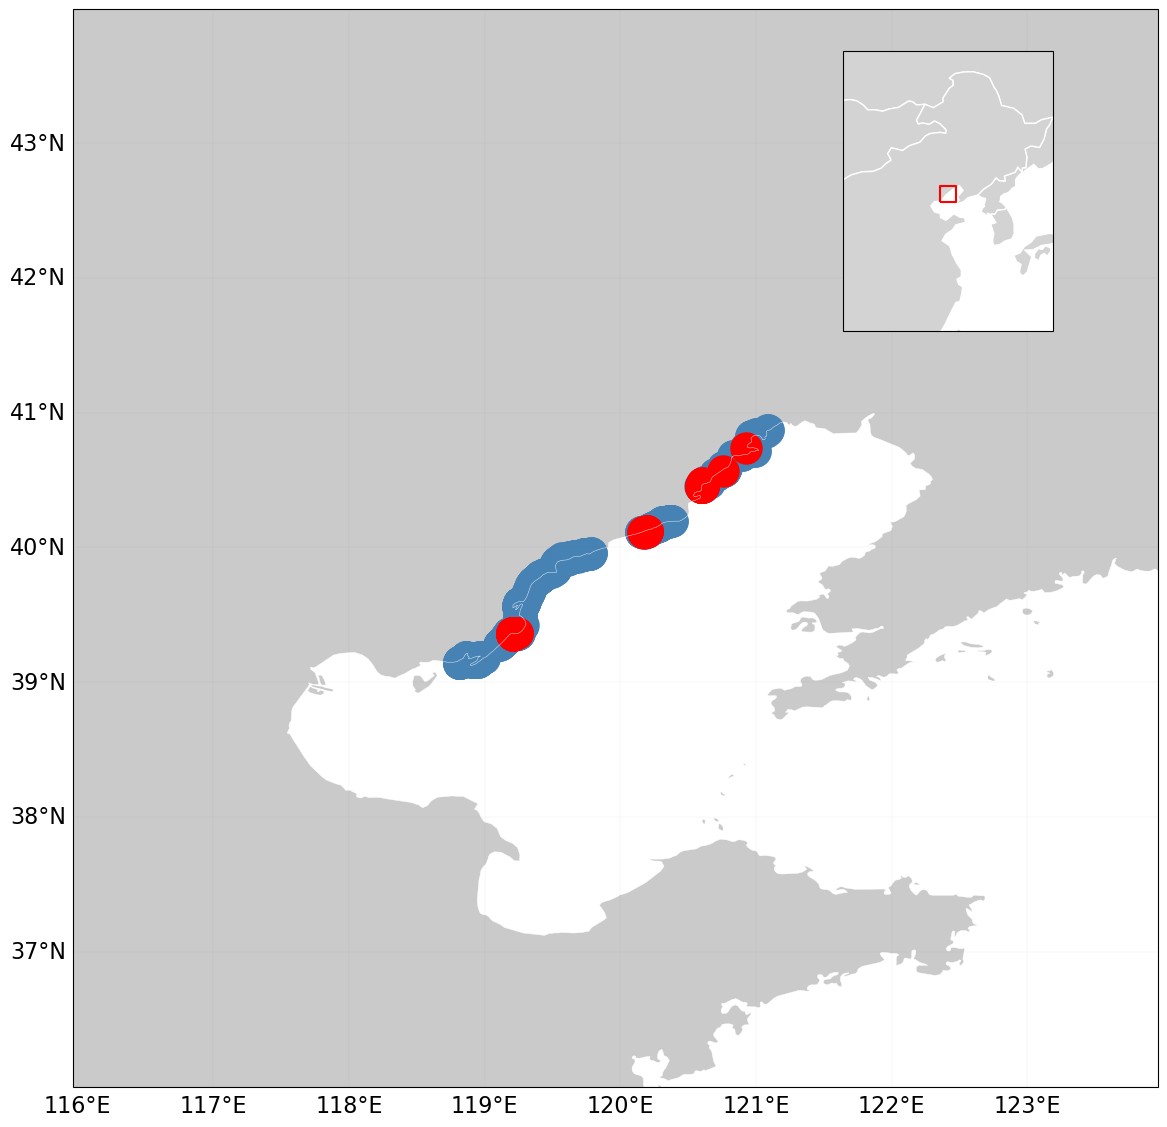

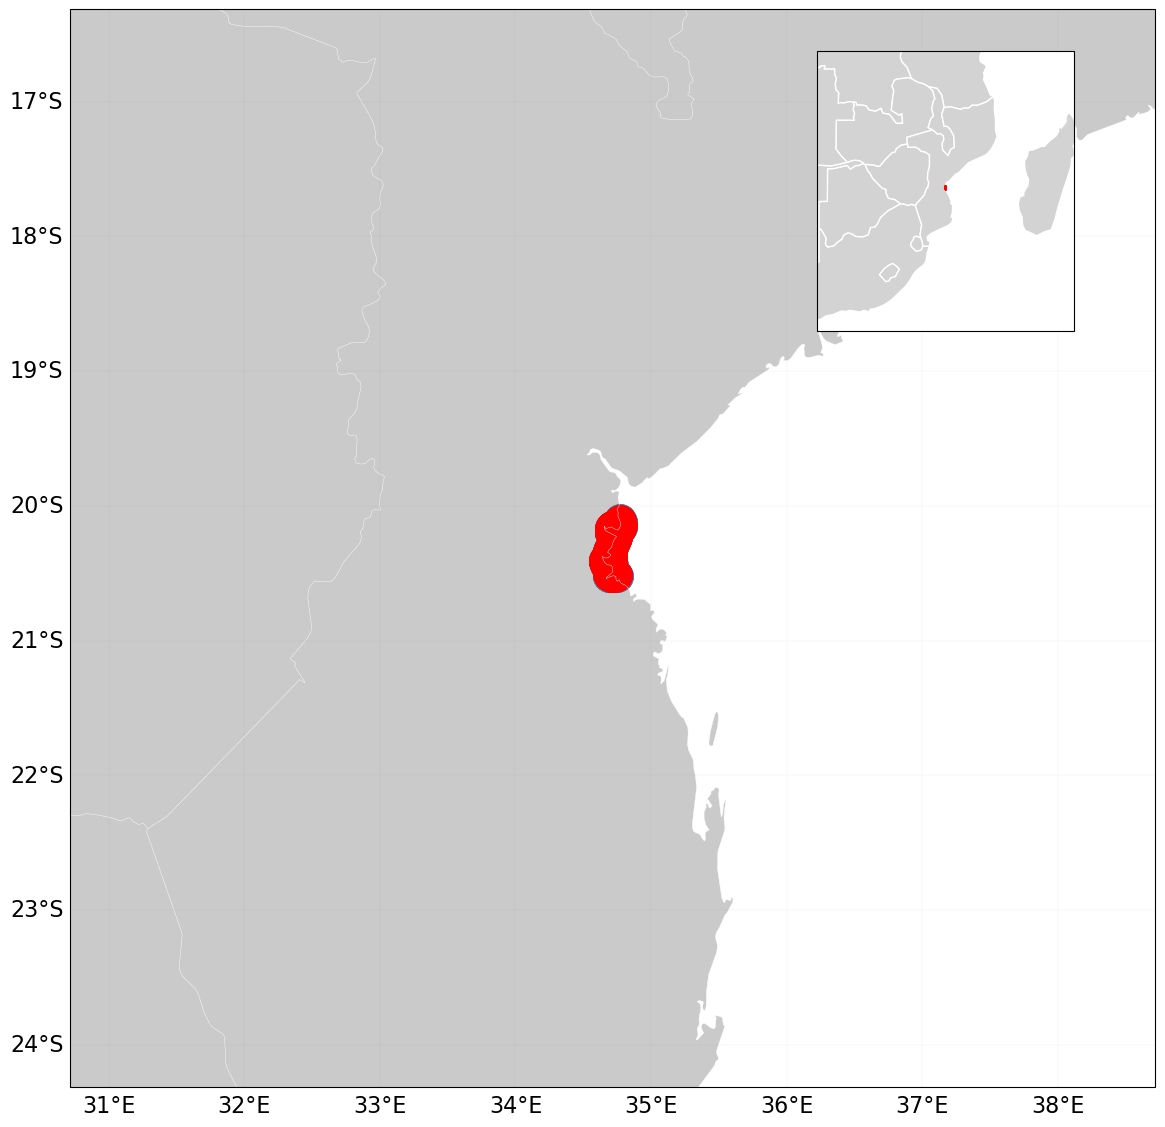

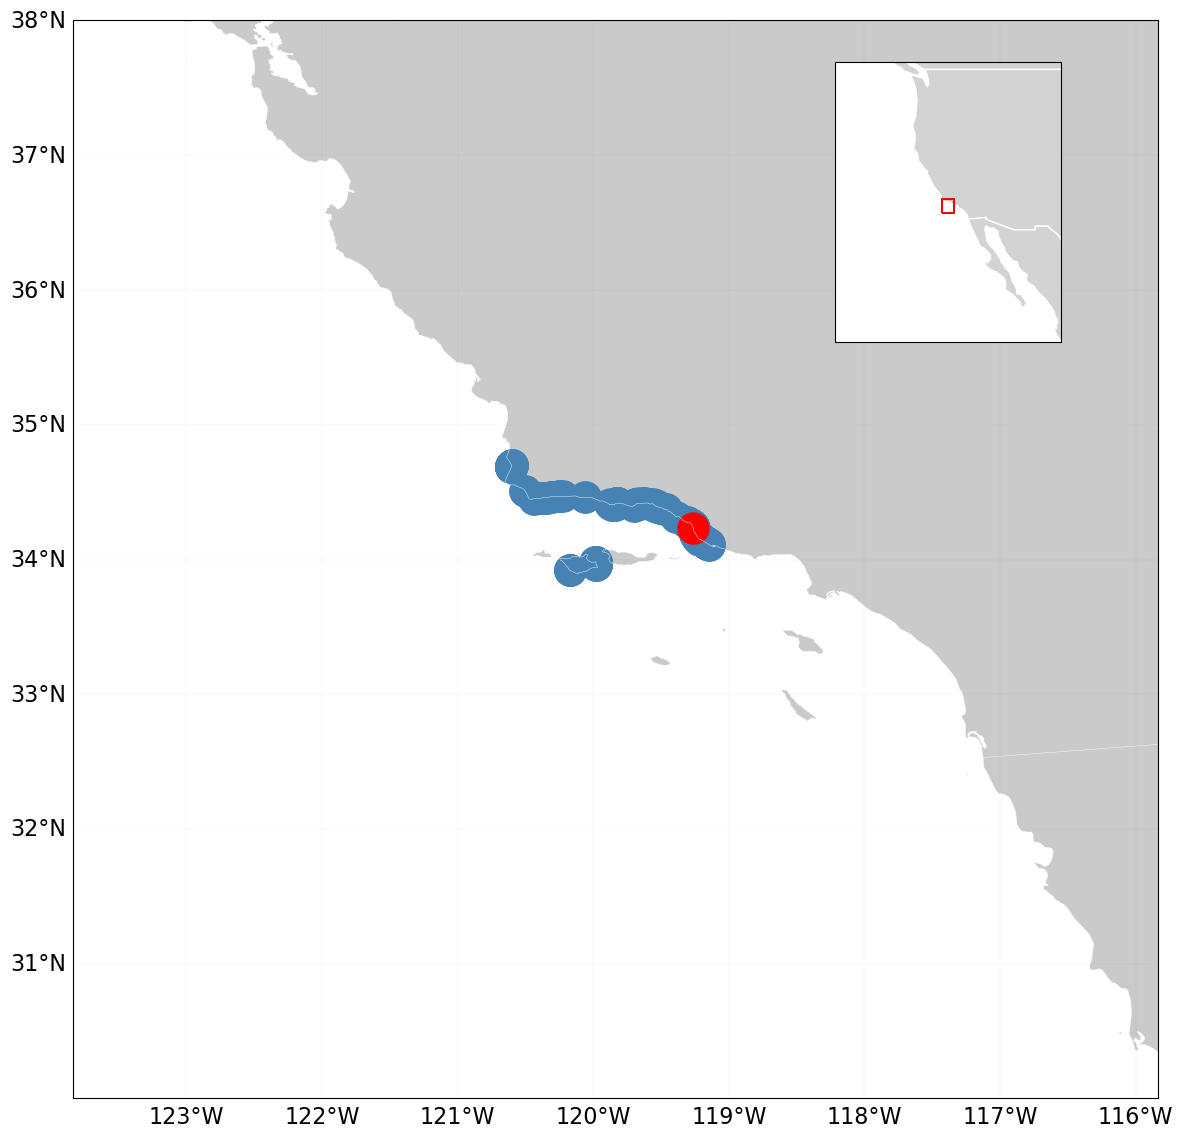

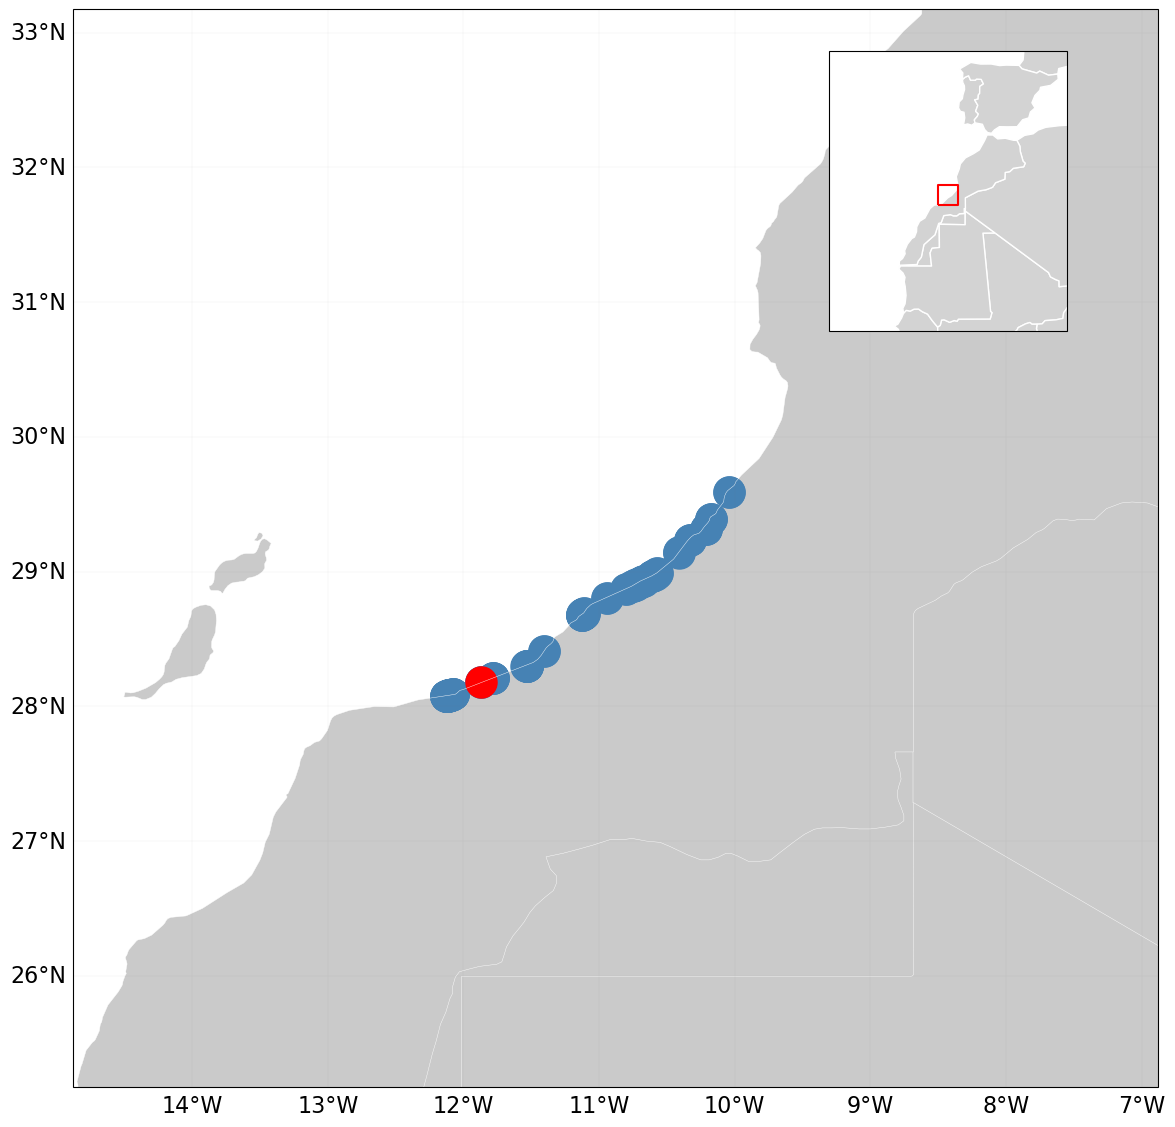

In [ ]:
# -----------------------------------
# location overview
# -----------------------------------

figs = []

h3_list = hazard_structure['h3'].unique()

for h3_group, title in zip(h3_list,loc_label):
    # print(h3_group)
    gambar, _ = inset_map(hazard_structure,h3_group,label='')
    figs.append(gambar)
#   

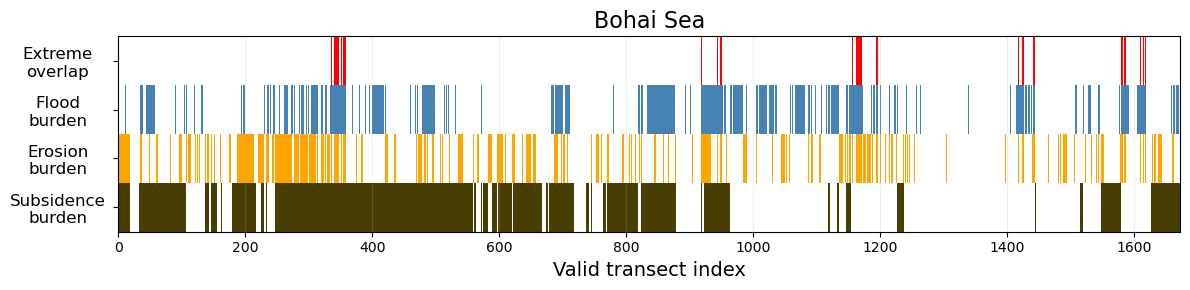

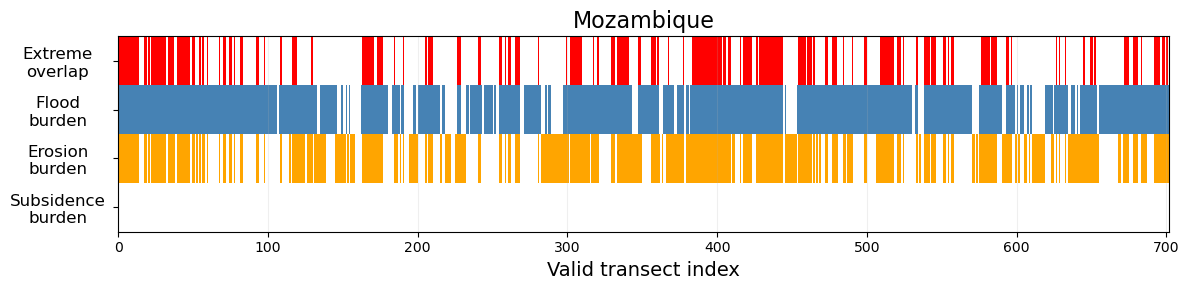

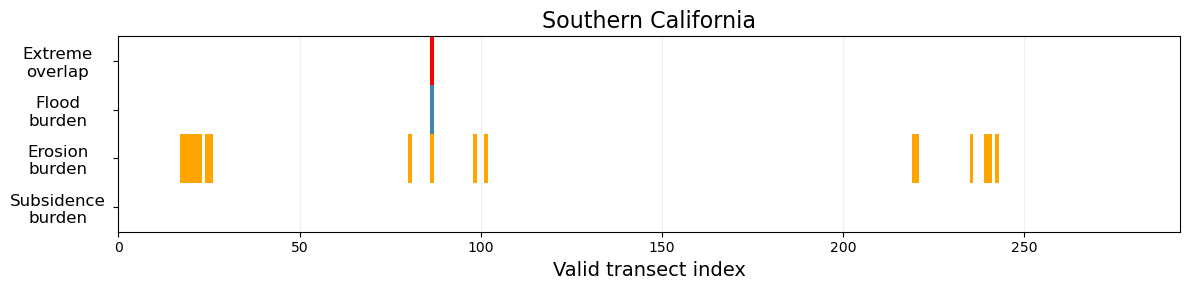

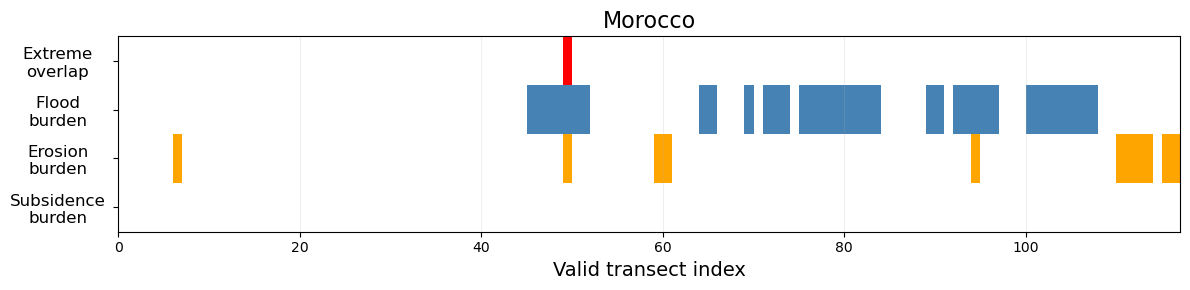

In [ ]:
# -----------------------------------
# hazard distribution in barcode
# -----------------------------------

F_extreme =  gdf["flood_mean"].quantile(0.90)
E_extreme =  gdf["erosion"].quantile(0.90)
S_extreme =  gdf["subsidence"].quantile(0.90)


bars = []


h3_list = hazard_structure['h3'].unique()



for cell, title in zip(h3_list,loc_label):
    # print(h3_group)



    df_u = hazard_structure[hazard_structure["h3"] == cell].copy()

    df_u["Flood"] = df_u["flood_mean"] >= 2
    df_u["Erosion"] = df_u["erosion"] >= 1
    df_u["Subsidence"] = df_u["subsidence"] >= 10
    df_u = df_u.dropna(subset=['flood_mean', 'erosion', 'subsidence'])
    bars.append(plot_overlap_index(df_u, label=title,
                flood_extreme = F_extreme, erosion_extreme = E_extreme,subsidence_extreme = S_extreme
                ))
#   

## 7. Global reference and regional amplification contrast

The absolute amplification factor indicates whether the conditional flood probability differs from the background probability within a region. A second question is whether a regional amplification signal is **stronger or weaker than the overall global compound-hazard structure**. The following analysis therefore establishes a global reference and expresses each regional H3 amplification relative to it.

Two global summaries are calculated. The first uses all available observations accepted by `amp_stats()`. The second uses a **complete-case subset**, retaining only transects for which flood, erosion, and subsidence are all available. The complete-case value is subsequently used as the common reference for regional comparison so that the numerator and reference are based on observations where all three hazard variables can be evaluated together.


In [14]:
# Expected: prints the global `amp_FES` obtained from all observations handled by `amp_stats`; use this mainly as a diagnostic comparison.
# all data
global_stats = amp_stats(gdf)
global_ref = global_stats['amp_FES']
print(f'Global amplification (P(F|E&S)/P(F)) value for all data = {global_ref:.2f}')

Global amplification (P(F|E&S)/P(F)) value for all data = 2.69


In [15]:
# Expected: prints the complete-case global `amp_FES`; this value becomes the reference used for regional normalization below.
# complete case
complete_case = gdf.dropna(subset=["flood_mean", "erosion", "subsidence"]).copy()
global_statistics = amp_stats(complete_case)
global_reference = global_statistics['amp_FES']
print(f'Global amplification value (P(F|E&S)/P(F)) for complete case data = {global_reference:.2f}')

Global amplification value (P(F|E&S)/P(F)) for complete case data = 0.98


### 6.1 Normalize regional amplification against the global reference

Each regional compound amplification value is divided by the complete-case global amplification:

$$
A_{relative}=\frac{A_{regional}}{A_{global}},
$$

and the plotted deviation is

$$
\Delta A=A_{relative}-1.
$$

This transformation centers the global reference at zero. A positive $\Delta A$ means that the regional compound amplification is stronger than the global reference, while a negative value means that it is weaker.

Before mapping, minimum-support filters are applied (`n_total >= 100` and `n_ES >= 10`). These filters reduce the influence of regional ratios calculated from very small samples, particularly where the joint erosion–subsidence extreme state occurs only a few times. They should be understood as robustness filters for the exploratory spatial comparison rather than as a formal significance test.


In [ ]:
amplification["amp_relative"] = amplification["amp_FES"] / global_reference
amplification["amp_delta"] = amplification["amp_relative"] - 1

amp_plot = amplification[
    (amplification["n_total"] >= 100) &
    (amplification["n_ES"] >= 10) &
    (amplification["amp_FES"].notna())
].copy()


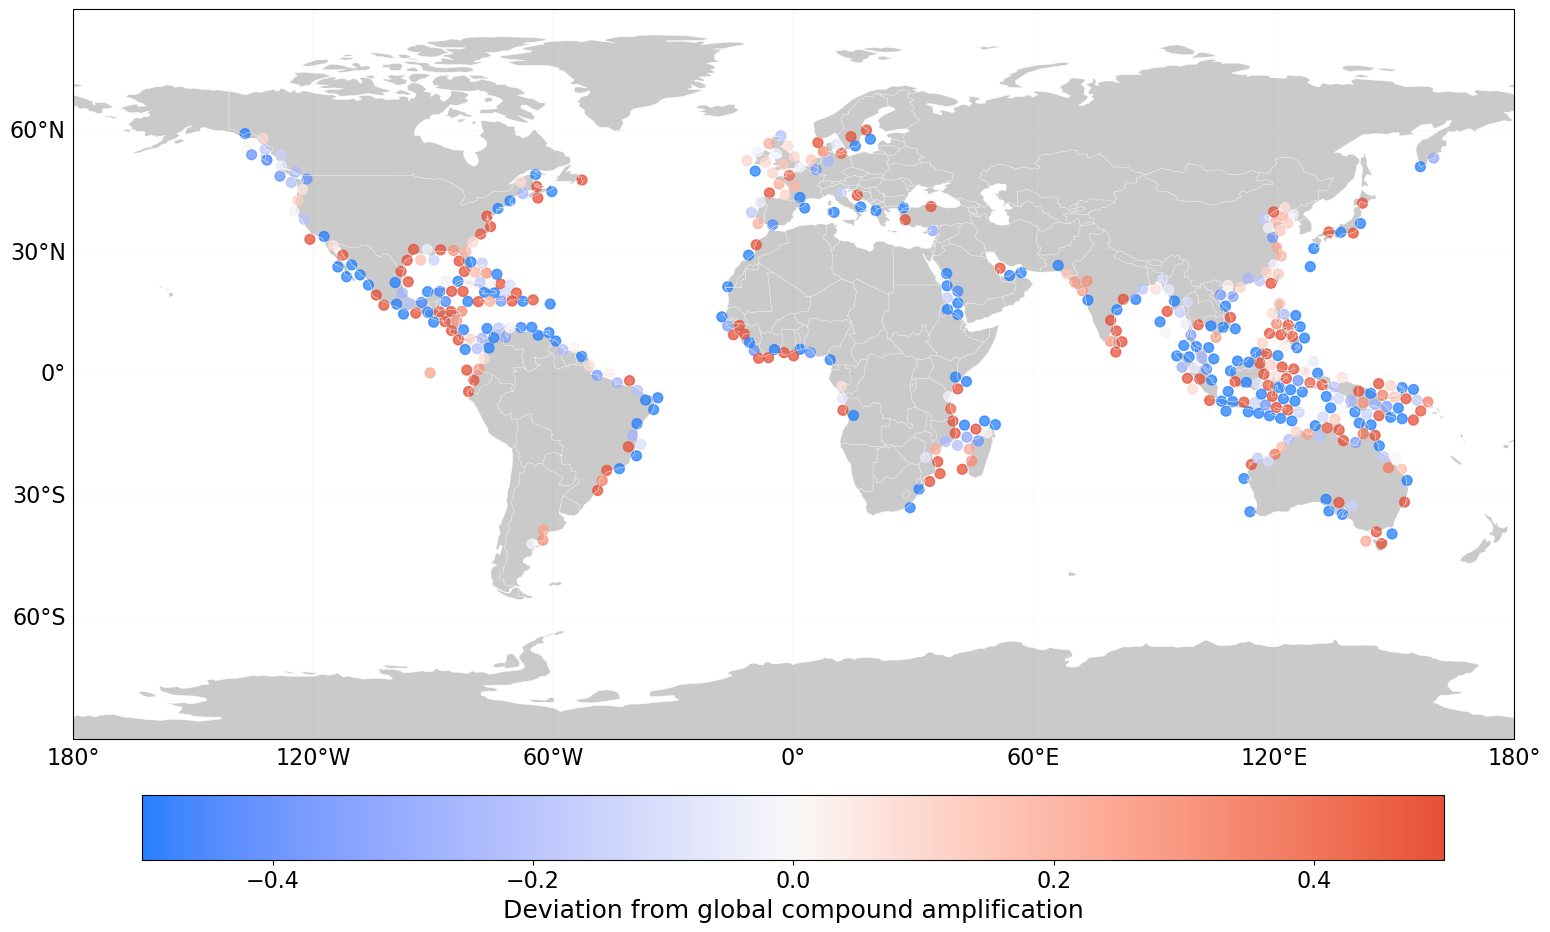

In [ ]:
size_raw = amp_plot["n_ES"]

size_norm = (
    np.sqrt(size_raw) /
    np.sqrt(size_raw.quantile(0.95))
).clip(0, 1)

amp_plot["size"] = 1 + size_norm * 100

norm = mcolors.TwoSlopeNorm(
    vmin=-0.5,
    vcenter=0,
    vmax=0.5
)

fig, ax = initialize_map(figsize=(24,12))

amp_plot.plot(
    column='amp_delta',
    cmap=cc.m_diverging_bwr_55_98_c37,
    ax=ax,
    markersize=50,
    norm=norm,
    transform=ccrs.PlateCarree(),
    legend=True,
    alpha=0.75,
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

# get colorbar axis
cbar_ax = fig.axes[-1]

# change colorbar label fontsize
cbar_ax.set_xlabel(
    "Deviation from global compound amplification",
    fontsize=18
)

# change colorbar tick fontsize
cbar_ax.tick_params(labelsize=16)
